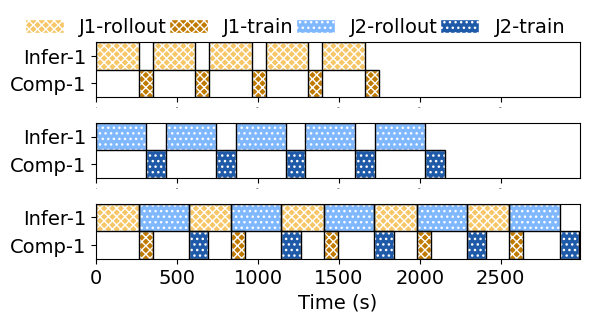

In [15]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib
import matplotlib.gridspec as gridspec
import matplotlib.patches as patches
from global_scheduler.new_simulator import WeaveSimulator
from global_scheduler.structs import Job

matplotlib.rcParams['pdf.fonttype'] = 42
matplotlib.rcParams['ps.fonttype'] = 42

blues = sns.color_palette('Blues')
fig = plt.figure(figsize=(6, 3))

j1 = Job('J1', 262.5, 86.75, rollout_nodes=['Infer-1'], train_nodes=['Comp-1'])
j2 = Job('J2', 310.125, 120.5, rollout_nodes=['Infer-1'], train_nodes=['Comp-1'])
color_settings = {
    "J1": ["#F6C667", "#C07A00", "XXXX"],
    "J2": ["#7FB8FF", "#1E5AA8", "..."],
}

n = 5
maxx = (n + 0.01) * (262.5 + 310.125) + 120.5

a0 = plt.subplot(311)
plt.sca(a0)
sim = WeaveSimulator([j1])
sim.plot(n, color_settings)
plt.yticks(fontsize=14)
plt.xticks(fontsize=0)
plt.xlim(0, maxx)


a1 = plt.subplot(312)
plt.sca(a1)
sim = WeaveSimulator([j2])
sim.plot(n, color_settings)
plt.xticks(fontsize=0)
plt.xlim(0, maxx)
plt.yticks(fontsize=14)

a2 = plt.subplot(313)
plt.sca(a2)
sim = WeaveSimulator([j1, j2])
sim.plot(n, color_settings)
plt.xlim(0, maxx)
plt.yticks(fontsize=14)
plt.xticks(fontsize=14)
plt.xlabel("Time (s)", fontdict={"fontsize": 14})

for job in color_settings:
    a0.add_patch(patches.Rectangle([0, 0], 0, 1, facecolor=color_settings[job][0], hatch=color_settings[job][2], label=f"{job}-rollout", edgecolor='white'))
    a0.add_patch(patches.Rectangle([0, 0], 0, 1, facecolor=color_settings[job][1], hatch=color_settings[job][2], label=f"{job}-train", edgecolor='white'))

lgd = plt.figlegend(ncols=4, fontsize=14, frameon=False, columnspacing=0.1, loc='center', bbox_to_anchor=(0.5, 1))
plt.tight_layout()
plt.savefig("bad_schedule.pdf", bbox_inches='tight', bbox_extra_artists=(lgd,))

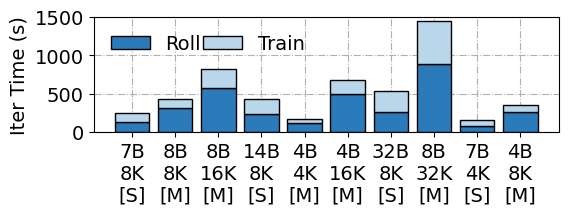

In [28]:
t = {}
t['disagg'] = {'4B_16k': {'generate': 496.0, 'train': 180.33333333333334}, '4B_8k': {'generate': 262.5, 'train': 86.75}, '4B_4k': {'generate': 121.5, 'train': 51.25}, '4B_32k': {'generate': 734.3333333333334, 'train': 464.6666666666667}, '7B_8k': {'generate': 133.8, 'train': 112.8}, '7B_4k': {'generate': 80.5, 'train': 77.0}, '32B_8k': {'generate': 267.6, 'train': 271.3333333333333}, '32B_4k': {'generate': 165.33333333333334, 'train': 219.33333333333334}, '14B_8k': {'generate': 238.6, 'train': 197.4}, '14B_4k': {'generate': 145.0, 'train': 126.66666666666667}, '8B_16k': {'generate': 580.5, 'train': 241.0}, '8B_8k': {'generate': 310.125, 'train': 120.5}, '8B_4k': {'generate': 140.57142857142858, 'train': 70.85714285714286}, '8B_32k': {'generate': 888.0, 'train': 559.5}, '3B_8k': {'generate': 128.33333333333334, 'train': 71.33333333333333}, '3B_4k': {'generate': 79.33333333333333, 'train': 47.0}}
popular_jobs = ['7B_8k', '8B_8k', '8B_16k', '14B_8k', '4B_4k', '4B_16k', '32B_8k', '8B_32k', '7B_4k', '4B_8k']
turns = ['S', 'M', 'M', 'S', 'M', 'M', 'S', 'M', 'S', 'M']
fig = plt.figure(figsize=(6, 1.5)) # 总体宽高
# gs = gridspec.GridSpec(
#     4, 2,
#     width_ratios=[1, 1.5],
#     height_ratios=[1, 1, 1, 0.15],
#     wspace=0.3,
#     hspace=0.1
# )

for i, j in enumerate(popular_jobs):
    plt.bar(i, t['disagg'][j]['generate'], color=blues[4], edgecolor='black', zorder=2, label='Roll' if i == 0 else None)
    plt.bar(i, t['disagg'][j]['train'], bottom=t['disagg'][j]['generate'], color=blues[1], edgecolor='black', zorder=2, label='Train' if i == 0 else None)
plt.xticks(np.arange(len(popular_jobs)), [popular_jobs[i].replace("_", "\n").upper() + '\n[' + turns[i] + ']' for i in range(len(popular_jobs))], fontsize=14)
plt.legend(fontsize=14, ncols=2, frameon=False, columnspacing=0.1)
plt.grid(linestyle='-.')
plt.yticks(fontsize=14)
plt.ylabel("Iter Time (s)", fontdict={"fontsize": 14})
plt.ylim(0, 1500)
plt.savefig("job_diversity.pdf", bbox_inches='tight')